In [1]:
# ============================================================
# DAY 5: RANDOM FOREST MODEL
# ============================================================
# Objective:
# Train a Random Forest classifier to predict customer churn.
# We will evaluate the model using Precision, Recall and F1-score
# and identify important features.
# ============================================================

import pandas as pd

# Load the initial engineered dataset created during Week 2
df = pd.read_csv("../data/initial_engineered_customer_dataset.csv")

# Display dataset dimensions
print("Dataset shape:", df.shape)

# Display first 5 rows
df.head()

Dataset shape: (7043, 36)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,HasInternetService,HasOnlineSecurity,HasOnlineBackup,HasDeviceProtection,HasTechSupport,HasStreamingTV,HasStreamingMovies,IsPaperlessBilling,IsAutoPayment,TotalServices
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,1,0,1,0,0,0,0,1,0,2
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,1,1,0,1,0,0,0,0,0,4
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,1,1,1,0,0,0,0,1,0,4
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,1,1,0,1,1,0,0,0,1,4
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,1,0,0,0,0,0,0,1,0,2


In [3]:
# ============================================
# STEP 2: PREPARE FEATURES AND TARGET
# ============================================

# Convert Churn from Yes/No into numeric values
# Yes = 1 means customer churned
# No = 0 means customer did not churn
df["ChurnNumeric"] = df["Churn"].map({"Yes": 1, "No": 0})

# Separate input features (X) from target variable (y)
# Churn and CustomerID are removed because they should not be used as predictors
X = df.drop(columns=["Churn", "ChurnNumeric", "customerID"])

# Target variable for Random Forest
y = df["ChurnNumeric"]

# Display the shapes for verification
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 34)
Target shape: (7043,)


In [6]:
# ============================================
# STEP 3: SPLIT DATA INTO TRAINING AND TESTING
# ============================================

from sklearn.model_selection import train_test_split

# Split the dataset into:
# 80% training data -> used to train the Random Forest model
# 20% testing data  -> used to evaluate the model on unseen data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the size of each dataset for verification
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (5634, 34)
Testing features shape: (1409, 34)
Training target shape: (5634,)
Testing target shape: (1409,)


In [8]:
# ============================================================
# STEP 4: ENCODE CATEGORICAL FEATURES
# ============================================================
# Random Forest model numerical values par kaam karta hai.
# Dataset me Male/Female, Yes/No jaise text values hain.
# Isliye categorical columns ko numerical format me convert kar rahe hain.

# Target aur Customer ID ko features se remove karna
X = df.drop(columns=["Churn", "ChurnNumeric", "customerID"])

# Target variable
y = df["ChurnNumeric"]

# Categorical columns ko One-Hot Encoding me convert karna
# drop_first=True unnecessary duplicate information ko avoid karta hai.
X = pd.get_dummies(X, drop_first=True)

# Boolean values ko integer (0/1) me convert karna
X = X.astype(int)

# Encoding ke baad dataset dimensions verify karna
print("Encoded features shape:", X.shape)
print("Target shape:", y.shape)

Encoded features shape: (7043, 6574)
Target shape: (7043,)


In [10]:
# ============================================================
# STEP 5: SPLIT DATA INTO TRAINING AND TESTING SETS
# ============================================================
# 80% data model training ke liye use hoga.
# 20% data model testing/evaluation ke liye use hoga.
# random_state=42 se same split baar-baar reproduce ho sakta hai.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Split ke baad dataset sizes verify karna
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (5634, 6574)
Testing features shape: (1409, 6574)
Training target shape: (5634,)
Testing target shape: (1409,)


In [11]:
# ============================================================
# STEP 6: TRAIN RANDOM FOREST CLASSIFIER
# ============================================================
# Random Forest customer churn ko predict karne ke liye train
# kiya ja raha hai.
#
# class_weight="balanced" churn classes ke imbalance ko handle
# karne me help karta hai.
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# Random Forest model create karna
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

# Model ko training data par train karna
rf_model.fit(X_train, y_train)

# Training completion verify karna
print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [12]:
# ============================================================
# STEP 7: MAKE PREDICTIONS ON TEST DATA
# ============================================================
# Trained Random Forest model ko test data par use karke
# customer churn predictions generate kar rahe hain.
# ============================================================

# Test dataset ke liye churn predictions generate karna
y_pred = rf_model.predict(X_test)

# Prediction results ki basic verification
print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

Predictions generated successfully.
Number of predictions: 1409


In [13]:
# ============================================================
# STEP 8: EVALUATE RANDOM FOREST MODEL
# ============================================================
# Actual churn values aur model ki predicted values ko compare
# karke model performance calculate kar rahe hain.
# ============================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display model performance
print("Random Forest Model Performance")
print("--------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Random Forest Model Performance
--------------------------------
Accuracy : 0.7587
Precision: 0.5399
Recall   : 0.6150
F1-Score : 0.5750


Matplotlib is building the font cache; this may take a moment.


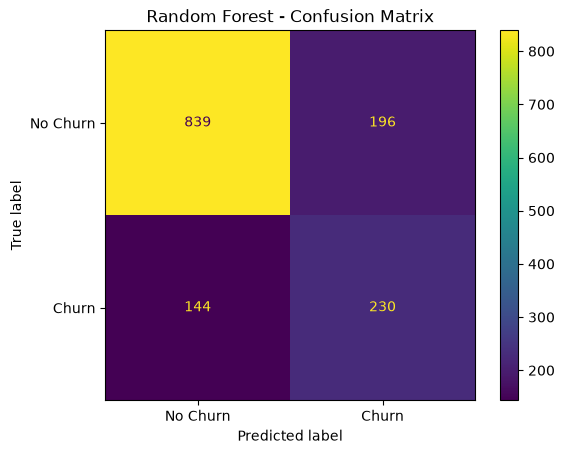

In [15]:
# ============================================================
# STEP 6: CONFUSION MATRIX
# ============================================================
# Confusion Matrix se hum dekhenge ki model ne:
# - Actual non-churn customers ko kitna sahi predict kiya
# - Actual churn customers ko kitna sahi predict kiya

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Actual values aur model predictions ke basis par confusion matrix banana
cm = confusion_matrix(y_test, y_pred)

# Confusion Matrix display karna
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()

Top 15 Important Features:


,Feature,Importance
1,tenure,0.106138
2,MonthlyCharges,0.068168
17,TotalServices,0.035633
39,Contract_Two year,0.033225
42,PaymentMethod_Electronic check,0.025660
24,InternetService_Fiber optic,0.024896
38,Contract_One year,0.022092
18,gender_Male,0.020396
9,HasOnlineSecurity,0.016261
27,OnlineSecurity_Yes,0.016068


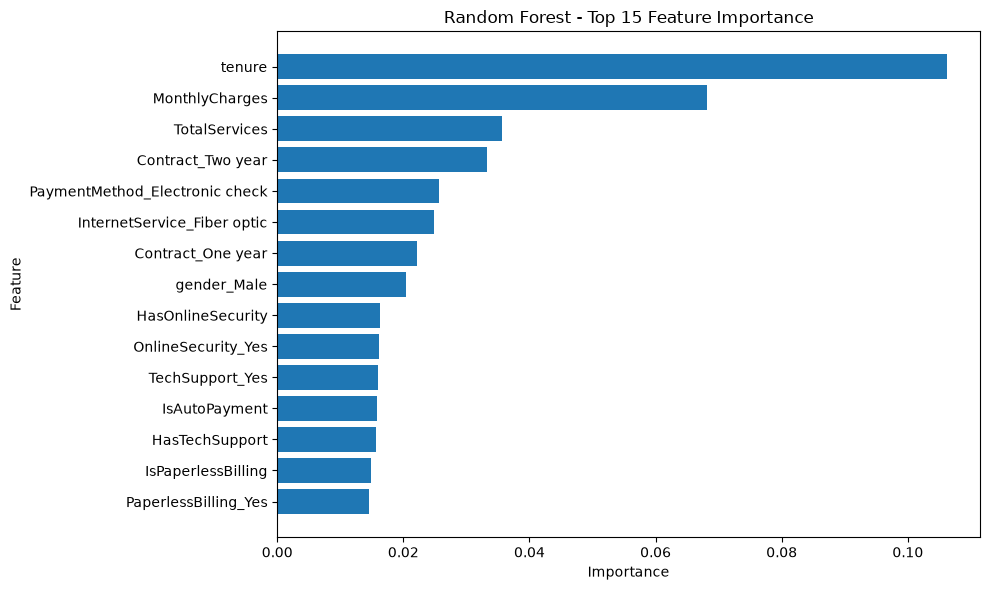

In [16]:
# ============================================================
# STEP 5: RANDOM FOREST FEATURE IMPORTANCE
# ============================================================
# Is step me hum identify karenge ki kaunse customer features
# churn prediction ke liye sabse important hain.
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Random Forest se feature importance values lena
feature_importance = rf_model.feature_importances_

# Feature names aur importance ko ek DataFrame me store karna
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importance
})

# Sabse important features ko upar rakhna
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Top 15 important features display karna
print("Top 15 Important Features:")
display(importance_df.head(15))

# Top 15 features ka bar chart banana
top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest - Top 15 Feature Importance")
plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# STEP 6: SAVE THE TRAINED RANDOM FOREST MODEL
# ============================================================
# Trained model ko file ke form me save kar rahe hain
# taaki future me model ko dobara train kiye bina use kar saken.
# ============================================================

import os
import joblib

# Model save karne ke liye models folder ka path
model_dir = "../models"

# Agar models folder nahi hai to create karna
os.makedirs(model_dir, exist_ok=True)

# Trained Random Forest model ko save karna
model_path = os.path.join(model_dir, "random_forest_churn_model.pkl")

joblib.dump(rf_model, model_path)

# Save hone ki verification
print("Random Forest model saved successfully.")
print("Model file:", model_path)

Random Forest model saved successfully.
Model file: ../models\random_forest_churn_model.pkl


In [18]:
# ============================================================
# STEP 7: FINAL DAY 5 MODEL SUMMARY
# ============================================================
# Is step me Day 5 ke Random Forest model ke important
# results ko ek jagah verify karenge.
# ============================================================

print("==============================================")
print("DAY 5 - RANDOM FOREST MODEL SUMMARY")
print("==============================================")

# Dataset information
print("Total customers       :", len(df))

# Train/Test information
print("Training samples       :", len(X_train))
print("Testing samples        :", len(X_test))

# Model performance
print("Accuracy               :", f"{accuracy:.4f}")
print("Precision              :", f"{precision:.4f}")
print("Recall                 :", f"{recall:.4f}")
print("F1-Score               :", f"{f1:.4f}")

# Model file verification
print("Model saved at         :", model_path)

print("==============================================")
print("Day 5 Random Forest workflow completed.")
print("==============================================")

DAY 5 - RANDOM FOREST MODEL SUMMARY
Total customers       : 7043
Training samples       : 5634
Testing samples        : 1409
Accuracy               : 0.7587
Precision              : 0.5399
Recall                 : 0.6150
F1-Score               : 0.5750
Model saved at         : ../models\random_forest_churn_model.pkl
Day 5 Random Forest workflow completed.
